In [3]:
from linearClassificationHelperFunctions import normalize,load_test, load_train_val, cross_entropy_loss, train_logistic, test_logistic_model, validate, softmax_manual, cross_entropy_softmax, train_softmax, test_softmax
import torch
from torch.utils.data import DataLoader, TensorDataset

In [4]:
x_train, x_val, y_train, y_val = load_train_val()
print(x_train.max(), x_train.min())
x_test, y_test = load_test()

x_train = normalize(x_train)
x_val = normalize(x_val)
x_test = normalize(x_test)

# Convert to tensors
x_train_t = torch.tensor(x_train, dtype=torch.float32 )
y_train_t = torch.tensor(y_train, dtype=torch.float32 )
x_val_t   = torch.tensor(x_val, dtype=torch.float32   )
y_val_t   = torch.tensor(y_val, dtype=torch.float32   )
x_test_t  = torch.tensor(x_test, dtype=torch.float32  )
y_test_t  = torch.tensor(y_test, dtype=torch.float32  )

# Keep only digits 0 and 1
binary_mask = (y_train_t == 0) | (y_train_t == 1)
x_train_bin = x_train_t[binary_mask]

y_train_bin = y_train_t[binary_mask]
print(x_train_bin.max(), x_train_bin.min())

binary_mask_val = (y_val_t == 0) | (y_val_t == 1)
x_val_bin = x_val_t[binary_mask_val]
y_val_bin = y_val_t[binary_mask_val]

binary_mask = (y_test_t == 0) | (y_test_t == 1)
x_test_bin = x_test_t[binary_mask]
y_test_bin = y_test_t[binary_mask]

# Create Datasets and Loaders
train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset = TensorDataset(x_val_t, y_val_t)
test_dataset = TensorDataset(x_test_t, y_test_t)


train_dataset_binary = TensorDataset(x_train_bin, y_train_bin)
val_dataset_binary = TensorDataset(x_val_bin, y_val_bin)
test_dataset_binary = TensorDataset(x_test_bin, y_test_bin)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

train_loader_binary = DataLoader(train_dataset_binary, batch_size=10, shuffle=True)
val_loader_binary = DataLoader(val_dataset_binary, batch_size=10)
test_loader_binary = DataLoader(test_dataset_binary, batch_size=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:",device)


255 0
tensor(1.) tensor(0.)
Device: cuda


# The Variables here

In [5]:
# Training loop
lr = 0.01
epochs = 20

# The Logistic Classification Training ALgorithm

Epoch 1, Loss: 0.0620576269
Epoch 26, Loss: 0.0042625515
Epoch 51, Loss: 0.0032280843
Epoch 76, Loss: 0.0027002988
Epoch 100, Loss: 0.0023503744


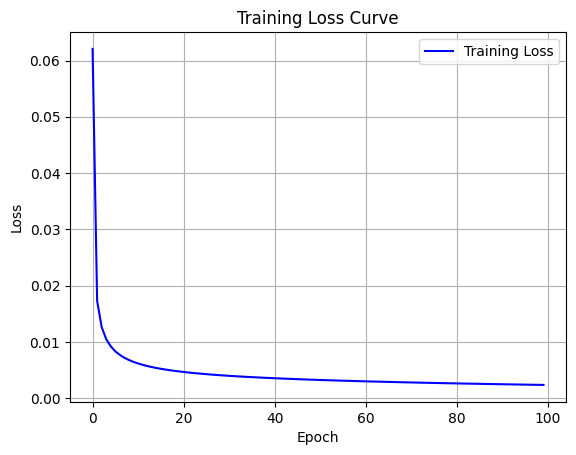

Training done!


In [6]:
W, b = train_logistic(train_loader_binary,lr=0.01,device=device,plot=True)

# Validation Algorithm

Testing lr:0.001
Epoch 1, Loss: 0.2513082987
Epoch 51, Loss: 0.0086381108
Epoch 101, Loss: 0.0062490395
Epoch 151, Loss: 0.0052529516
Epoch 200, Loss: 0.0046773932


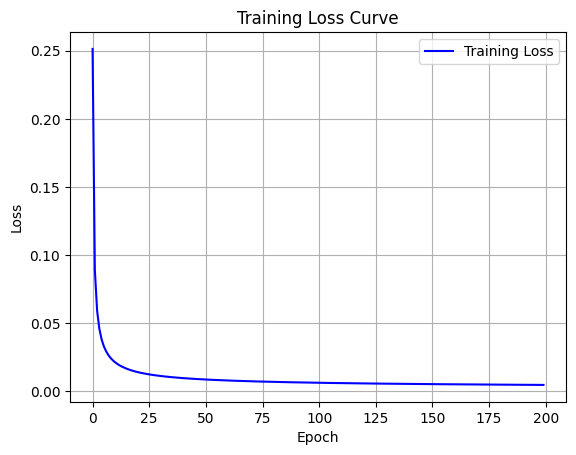

Training done!
Test Accuracy: 99.80%
Test Cross-Entropy Loss: 0.0072

Testing lr:0.01
Epoch 1, Loss: 0.0623100425
Epoch 51, Loss: 0.0032278834
Epoch 101, Loss: 0.0023349443
Epoch 151, Loss: 0.0018446245
Epoch 200, Loss: 0.0015231390


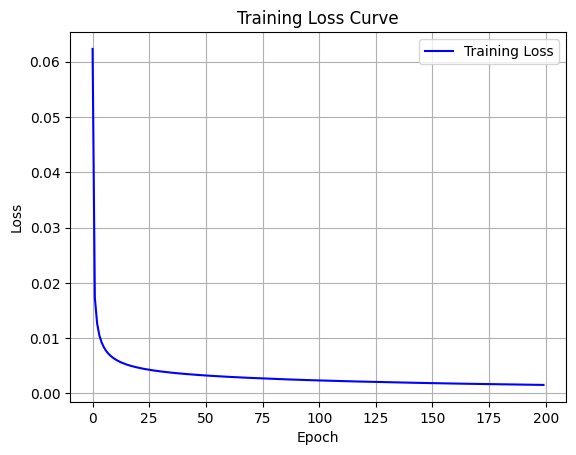

Training done!
Test Accuracy: 99.80%
Test Cross-Entropy Loss: 0.0054

Testing lr:0.1
Epoch 1, Loss: 0.0153458829
Epoch 51, Loss: 0.0007266291
Epoch 101, Loss: 0.0003880732
Epoch 151, Loss: 0.0002677440
Epoch 200, Loss: 0.0002059155


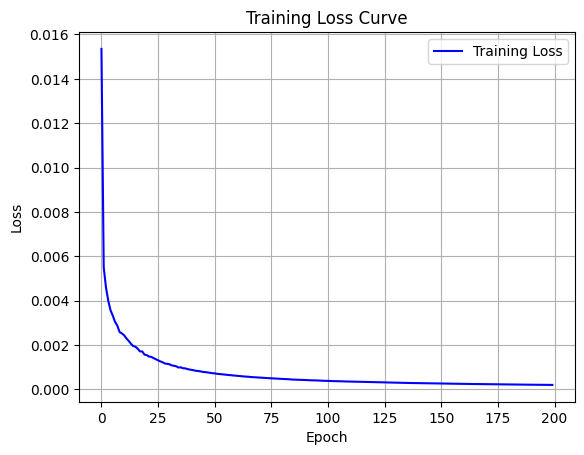

Training done!
Test Accuracy: 99.80%
Test Cross-Entropy Loss: 0.0062

Testing lr:1.0
Epoch 1, Loss: 0.0104039599
Epoch 51, Loss: 0.0000741160
Epoch 101, Loss: 0.0000405723
Epoch 151, Loss: 0.0000284442
Epoch 200, Loss: 0.0000218603


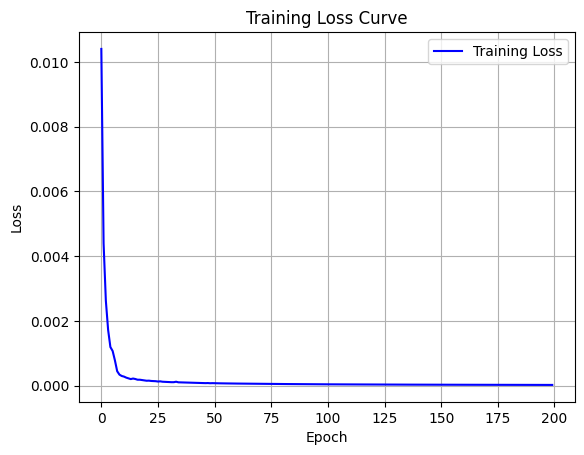

Training done!
Test Accuracy: 99.80%
Test Cross-Entropy Loss: 0.0087

Best learning rate: 1.000e-02    Validation CE: 0.005351


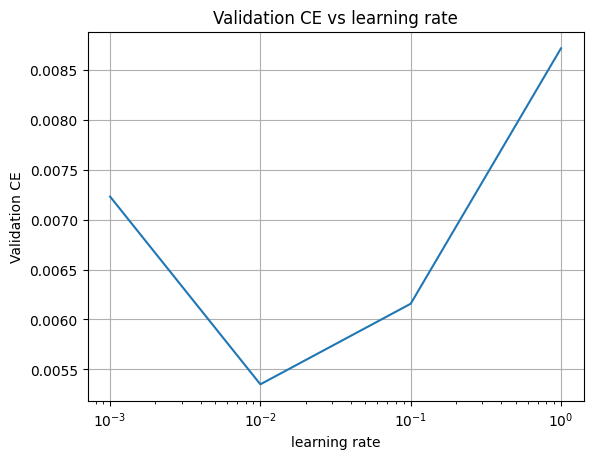

In [7]:
best_logistic_lr = validate(train_func= train_logistic, 
                            test_func=test_logistic_model,
                            train_loader=train_loader_binary,
                            val_loader=val_loader_binary,
                            device = device,
                            epochs = 200,
                            plot=True
                            )

In [8]:
W, b = train_logistic(train_loader_binary,lr=best_logistic_lr, device=device)
test_logistic_model(W,b,test_loader=test_loader_binary,device=device,cm_print=True)

Epoch 1, Loss: 0.0624986793
Epoch 26, Loss: 0.0042660017
Epoch 51, Loss: 0.0032315738
Epoch 76, Loss: 0.0027008023
Epoch 100, Loss: 0.0023508839
Training done!
Test Accuracy: 99.95%
Test Cross-Entropy Loss: 0.0017
Confusion Matrix:
 [[ 979    1]
 [   0 1135]]


0.0016732356865303535

# Softmax Training

Epoch 1, Loss: 1.0591731399
Epoch 26, Loss: 0.3156251968
Epoch 51, Loss: 0.2911838449
Epoch 76, Loss: 0.2796137942
Epoch 100, Loss: 0.2726918295


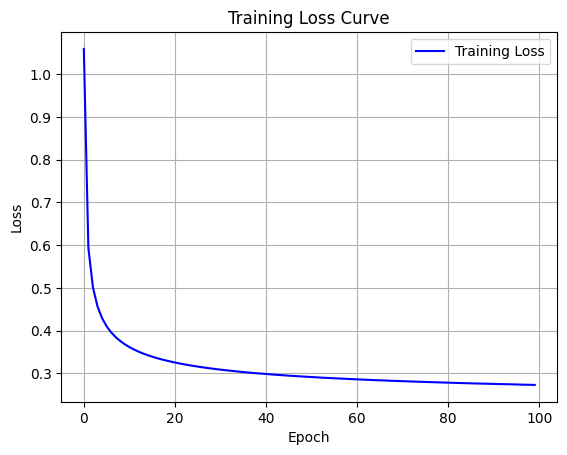

Training done!


(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0', requires_grad=True),
 tensor([-0.4051,  0.3672,  0.1879, -0.3195,  0.0352,  1.4980, -0.1040,  0.7039,
         -1.6362, -0.3275], device='cuda:0', requires_grad=True))

In [9]:
train_softmax(train_loader,epochs = 100, lr = 0.01, device=device, plot = True)

# Test Softmax

Testing lr:0.001
Epoch 1, Loss: 1.9689750714
Epoch 126, Loss: 0.3497965832
Epoch 251, Loss: 0.3157433643
Epoch 376, Loss: 0.3002513446
Epoch 500, Loss: 0.2908639426


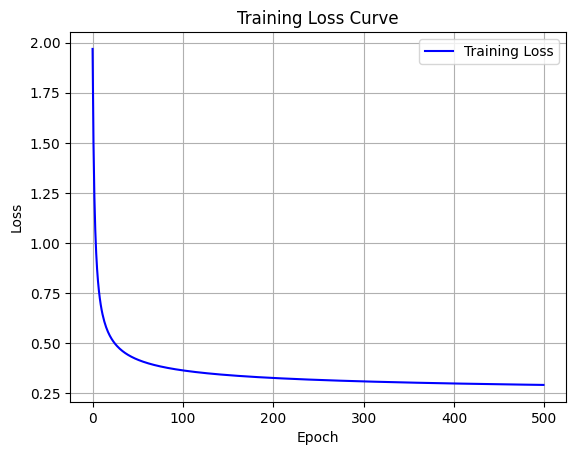

Training done!
Test Accuracy: 91.48%
Test Cross-Entropy Loss: 0.3036
Confusion Matrix:
 [[1146    0    4    1    2   10    6    1   14    1]
 [   0 1300   10    8    1    4    3    2   18    2]
 [   6   18 1043   19   20    3   19   13   44    7]
 [   6    5   36 1077    0   38    6   17   31   10]
 [   3    5   11    2 1077    1    8    1    7   53]
 [  14   10    8   37   11  951   14    4   22   13]
 [   7    4    7    0   14   23 1123    1    5    0]
 [   6    9   22    6    7    4    1 1150    4   44]
 [   7   26   10   32    8   30    9    4 1029   15]
 [   7   10    2   13   28    4    1   35    8 1082]]

Testing lr:0.01
Epoch 1, Loss: 1.0584529407
Epoch 126, Loss: 0.2674208119
Epoch 251, Loss: 0.2536998442
Epoch 376, Loss: 0.2466561876
Epoch 500, Loss: 0.2420811033


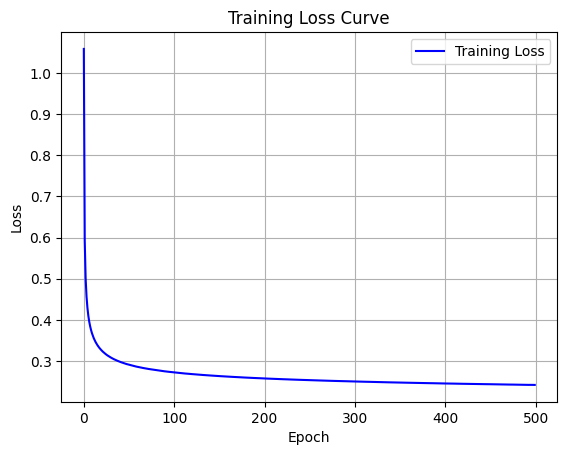

Training done!
Test Accuracy: 92.22%
Test Cross-Entropy Loss: 0.2779
Confusion Matrix:
 [[1151    0    3    0    1   13    8    1    6    2]
 [   0 1306   10    5    1    4    2    1   16    3]
 [   7   16 1062   25   12    4   20    8   34    4]
 [   4    4   34 1090    0   36    3   11   32   12]
 [   4    4    8    0 1088    1   10    3    7   43]
 [  11    5   10   28   14  961   13    4   26   12]
 [   7    3    5    0   12   24 1128    0    4    1]
 [   2    6   16    5   12    3    1 1166    4   38]
 [  12   24   13   30    6   35   10    3 1030    7]
 [   4   10    2   12   29    7    1   34    7 1084]]

Testing lr:0.1
Epoch 1, Loss: 0.5047613675
Epoch 126, Loss: 0.2329605855
Epoch 251, Loss: 0.2243720026
Epoch 376, Loss: 0.2197952400
Epoch 500, Loss: 0.2167538904


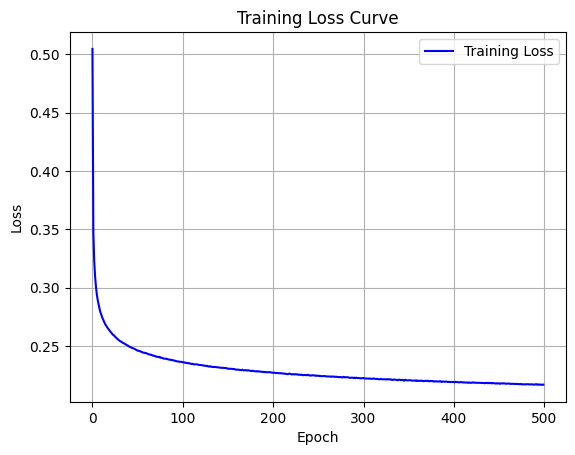

Training done!
Test Accuracy: 92.00%
Test Cross-Entropy Loss: 0.2977
Confusion Matrix:
 [[1141    0    4    1    1   21    9    1    4    3]
 [   0 1306   11    4    1    6    2    1   14    3]
 [   8   12 1072   23    8    4   19    7   33    6]
 [   3    5   41 1085    1   40    1    8   30   12]
 [   5    3    6    1 1078    2   11    7    7   48]
 [   9    2    9   27   13  970   14    2   26   12]
 [   6    2    7    1   11   24 1129    0    3    1]
 [   1    4   18    4    8    3    2 1167    4   42]
 [  13   23   16   29    5   42   15    3 1007   17]
 [   3    9    2   12   23    9    1   41    5 1085]]

Testing lr:1.0
Epoch 1, Loss: 0.4402306760
Epoch 126, Loss: 0.2577052868
Epoch 251, Loss: 0.2506706861
Epoch 376, Loss: 0.2459016632
Epoch 500, Loss: 0.2455551009


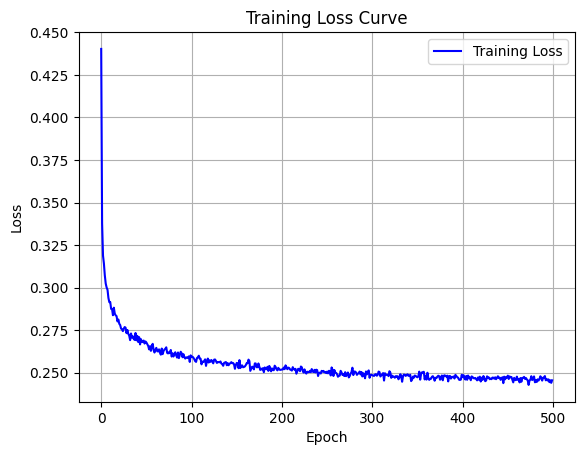

Training done!
Test Accuracy: 90.65%
Test Cross-Entropy Loss: 0.3802
Confusion Matrix:
 [[1148    0    3    2    0   10   10    1    8    3]
 [   0 1292   10   11    1    3    3    1   23    4]
 [  12   18 1038   41    9    6   24    6   32    6]
 [   4    5   31 1114    2   24    1    3   29   13]
 [   7    3    7    1 1058    2   11    7   10   62]
 [  10    3   11   55   14  896   25    1   56   13]
 [   8    2    6    1   14   15 1128    0    9    1]
 [   5    5   15   16   15    1    2 1110    8   76]
 [  18   19   13   56    6   25   17    2 1001   13]
 [   3    8    3   20   21   10    2   25    5 1093]]

Best learning rate: 1.000e-02    Validation CE: 0.277868


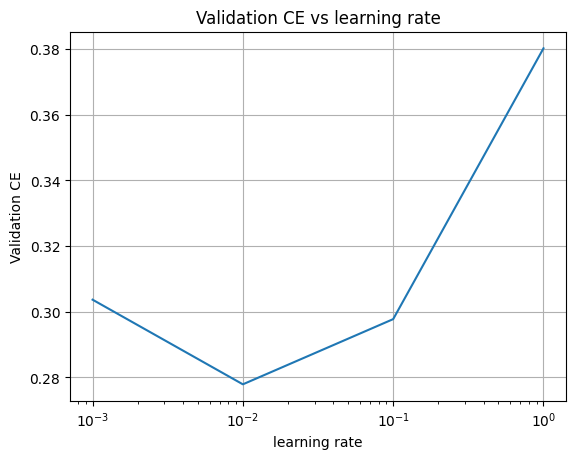

In [10]:
best_softmax_lr = validate(train_func=train_softmax,
                           test_func=test_softmax,
                           train_loader=train_loader,
                           val_loader=val_loader,
                           device=device,
                           epochs = 500, plot=True
                           )

In [11]:
W, b = train_softmax(train_loader,
                     epochs = 200,
                     lr=best_softmax_lr,
                     device=device
                     )

test_softmax(W = W,
             b = b,
             test_loader=test_loader,
             device=device,
             cm_print=True
             )

Epoch 1, Loss: 1.0590951884
Epoch 51, Loss: 0.2911190972
Epoch 101, Loss: 0.2724875772
Epoch 151, Loss: 0.2635279907
Epoch 200, Loss: 0.2578917672
Training done!
Test Accuracy: 92.31%
Test Cross-Entropy Loss: 0.2716
Confusion Matrix:
 [[ 960    0    2    3    0    6    6    1    2    0]
 [   0 1109    3    2    0    1    4    2   14    0]
 [   5    9  921   15   10    3   13   11   39    6]
 [   4    0   18  918    0   25    3   11   19   12]
 [   1    2    6    1  916    0   10    3    8   35]
 [  10    2    4   33   10  774   16    5   31    7]
 [  11    3    5    2    9   14  909    3    2    0]
 [   1    8   24    7    9    1    0  947    2   29]
 [   7    7    7   20    9   25   11   12  868    8]
 [  11    8    1    8   31    6    0   27    8  909]]


0.27160035445690156